In [1]:
import chipwhisperer as cw
import os, time

# (Assuming scope and target are already connected)
#bitstream_path =  r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado_\cw305_aes.runs\impl_100t\cw305_top.bit'
bitstream_path =  r'/home/sareeta/chipwhisperer/firmware/fpgas/aes/vivado/cw305_aes.runs/impl_100t/cw305_top.bit'
assert os.path.isfile(bitstream_path), f"Bitstream not found: {bitstream_path}"

# 2) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()

# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", bitstream_path)
target = cw.target(scope, cw.targets.CW305, bsfile=bitstream_path, force=True)


(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.51.0) is outdated - latest is 0.54.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1555663                   to 23038926                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (/home/sareeta/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", EXP_CT.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == EXP_CT)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
# Set target round to 10 (the final round)
target.fpga_write(0x0C, [8]) 

# Run AES
target.fpga_write(target.REG_CRYPT_GO, [0x01])
time.sleep(0.01)

# Read both
ct = target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16)
snap = target.fpga_read(0x0E, 16)

print(f"Cipherout: {ct.hex().upper()}")
print(f"Snapshot : {snap.hex().upper()}")

Cipherout: 06F36A65E8A99FF8907B2E5E5DDD77DE
Snapshot : C3EF9D9E3908C4D3B50BF2948B08FE07


In [6]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


In [7]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


In [8]:
scope.adc.samples        = 200   # enough to cover full AES
scope.adc.presamples     = 100


Trace length: 200


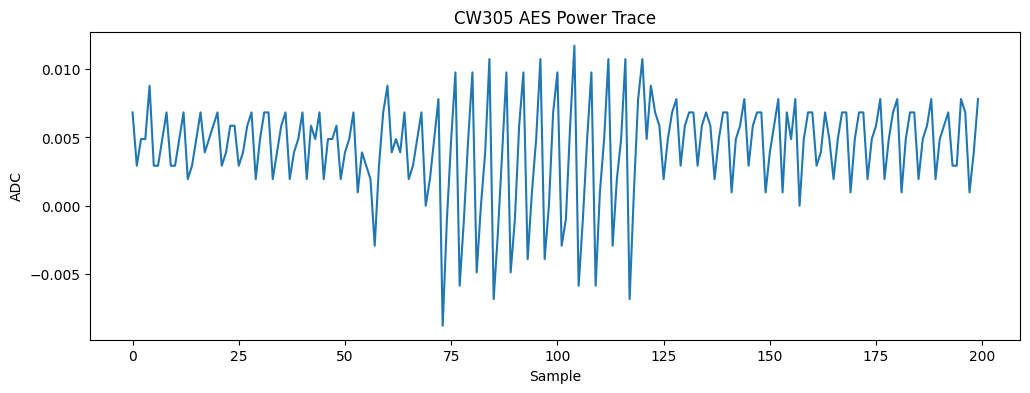

In [9]:

#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
#KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
#PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

ADC locked: True
Trace length: 1000


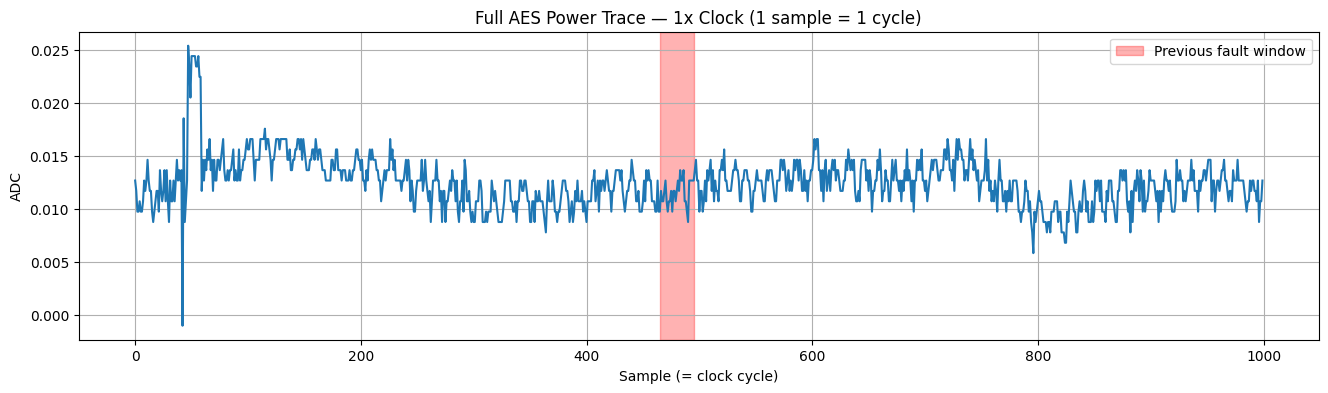

In [17]:
# Match ADC rate to crypto clock exactly
scope.clock.adc_src = "clkgen_x1"   # 1 sample per clock cycle
import time
import numpy as np
time.sleep(0.1)
print("ADC locked:", scope.clock.adc_locked)

scope.adc.samples    = 1000   # 1000 cycles should cover full AES
scope.adc.presamples = 50
scope.gain.db        = 35

# Capture clean trace
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x00")
target.fpga_write(target.REG_CRYPT_GO, b"\x01")
scope.capture()

full_trace = np.array(scope.get_last_trace(), dtype=np.float32)
print("Trace length:", len(full_trace))

import matplotlib.pyplot as plt
plt.figure(figsize=(16, 4))
plt.plot(full_trace)
plt.title("Full AES Power Trace — 1x Clock (1 sample = 1 cycle)")
plt.xlabel("Sample (= clock cycle)")
plt.ylabel("ADC")
plt.grid(True)

# Mark where your fault window was
plt.axvspan(465, 495, color='red', alpha=0.3, label='Previous fault window')
plt.legend()
plt.show()

In [10]:
import numpy as np

# AES-128 structure:
# Round 0 (initial): ~80 cycles (includes KeyExpansion)
# Rounds 1-9: remaining ~440 cycles / 9 rounds = ~49 cycles each

AES_START    = 75    # where rounds begin (after initial spike)
AES_END      = 125   # where AES finishes
TOTAL_CYCLES = AES_END - AES_START   # = 440 cycles for rounds 1-9
ROUND_PERIOD = TOTAL_CYCLES / 9      # ≈ 49 cycles per round

print(f"Estimated round period: {ROUND_PERIOD:.1f} cycles")
print()
print("Estimated round boundaries:")
for r in range(10):
    start = int(AES_START + r * ROUND_PERIOD)
    end   = int(AES_START + (r+1) * ROUND_PERIOD)
    print(f"  Round {r}: samples {start} - {end}  →  ext_offset ≈ {start}")

Estimated round period: 5.6 cycles

Estimated round boundaries:
  Round 0: samples 75 - 80  →  ext_offset ≈ 75
  Round 1: samples 80 - 86  →  ext_offset ≈ 80
  Round 2: samples 86 - 91  →  ext_offset ≈ 86
  Round 3: samples 91 - 97  →  ext_offset ≈ 91
  Round 4: samples 97 - 102  →  ext_offset ≈ 97
  Round 5: samples 102 - 108  →  ext_offset ≈ 102
  Round 6: samples 108 - 113  →  ext_offset ≈ 108
  Round 7: samples 113 - 119  →  ext_offset ≈ 113
  Round 8: samples 119 - 125  →  ext_offset ≈ 119
  Round 9: samples 125 - 130  →  ext_offset ≈ 125


In [11]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


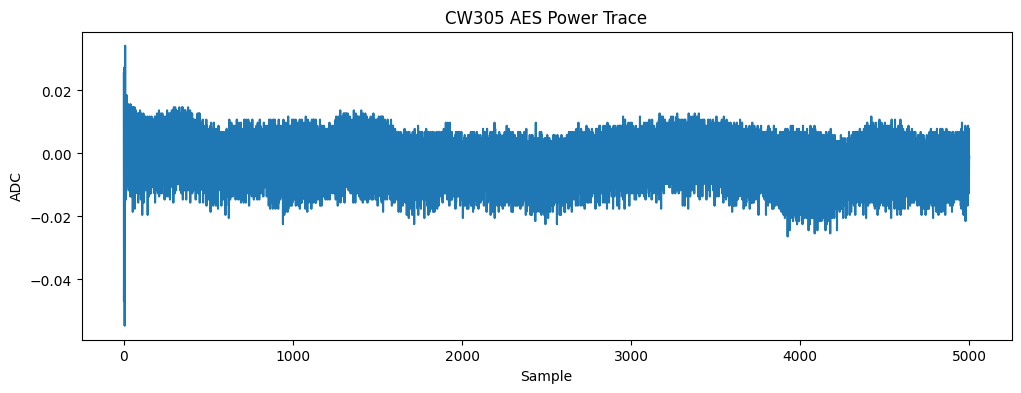

In [12]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [13]:
import numpy as np

# Convert lists to numpy arrays for efficient storage
traces_array = np.array(traces, dtype=np.float32)
pts_array = np.array([list(p) for p in pts], dtype=np.uint8)
cts_array = np.array([list(c) for c in cts], dtype=np.uint8)

# Save to a single compressed file
file_name = "normalaes_capture_10k.npz"
np.savez_compressed(file_name, 
                    traces=traces_array, 
                    pts=pts_array, 
                    cts=cts_array)

print(f"Successfully saved {len(traces)} traces to {file_name}")

Successfully saved 10000 traces to normalaes_capture_10k.npz


In [10]:
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0

In [11]:
scope.glitch.trigger_src ="continuous" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor"

In [12]:
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5   
print("Glitch ready.")

Glitch ready.


In [15]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

0 correct 06f36a65e8a99ff8907b2e5e5ddd77de
1 correct 06f36a65e8a99ff8907b2e5e5ddd77de
2 correct 06f36a65e8a99ff8907b2e5e5ddd77de
3 correct 06f36a65e8a99ff8907b2e5e5ddd77de
4 correct 06f36a65e8a99ff8907b2e5e5ddd77de
5 correct 06f36a65e8a99ff8907b2e5e5ddd77de
6 correct 06f36a65e8a99ff8907b2e5e5ddd77de
7 correct 06f36a65e8a99ff8907b2e5e5ddd77de
8 correct 06f36a65e8a99ff8907b2e5e5ddd77de
9 correct 06f36a65e8a99ff8907b2e5e5ddd77de


In [15]:
import numpy as np

# Configuration
N_PER_SETTING = 5
records = []
traces = []
labels = []
faults = []
hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

# Range Setup
widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off
        
        for rep in range(N_PER_SETTING):
            # --- THE WORKING LOGIC FROM CODE 1 ---
            scope.arm()
            
            # Launch AES
            target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
            target.fpga_write(target.REG_CRYPT_GO, b"\x01")
            
            # Capture the hardware result
            cap_timeout = scope.capture()
            ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
            
            # Trace processing (from Code 2)
            tr = None
            if not cap_timeout:
                tr = np.array(scope.get_last_trace(), dtype=np.float32)
            # --------------------------------------

            # Labeling Logic
            if cap_timeout:
                label = "no_trigger"
            elif ct == EXP_CT:
                label = "correct"
            else:
                label = "faulty"
                faults.append((w, off, ct.hex()))
                print(f"FAULT! w={w} off={off} ct={ct.hex()}")

            # Store in Hits dictionary
            hits[label] += 1

            # Create the record (from Code 2)
            records.append({
                "width": w,
                "offset": off,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # Store trace if it exists
            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total records:", len(records))

Starting Glitch Loop...
FAULT! w=-49 off=1 ct=77ab24b723633b7072092d1e881cb242
FAULT! w=-49 off=1 ct=a2a4b2d7f220cf8942e9dba5c03214ff
FAULT! w=-47 off=1 ct=684d6dacf29c9c6308e2b622ec0b8ad6
FAULT! w=-45 off=-5 ct=5ad67a8444f018875d37ac9b8b5e674e
FAULT! w=-31 off=1 ct=066748f06627fd543ab9a5864b13fffa


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=-15 off=1 ct=db28f5469f7e0c5a17538f3a2f075825


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=-7 off=-43 ct=7cba0fb1d65a3ca07c557b57932338cd


...

FAULT! w=5 off=45 ct=cdf36ad31fa99f80d17b8ae8b1aa7768
FAULT! w=5 off=47 ct=a979ccfbe0f036900bc091f0fb8dd125
FAULT! w=5 off=47 ct=2739d2dd800b13ae458a77e0184bb76a


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=7 off=45 ct=12fa411987201b0c336c820add1a7dd3


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=23 off=27 ct=a36ba87a5ee0668f124263ddd42b4e6e
FAULT! w=23 off=27 ct=fe3b7a361f35e8de9fa0f086b651d0f1

--- Scan Complete ---
Summary: {'correct': 11441, 'faulty': 21, 'no_trigger': 543}
Total records: 12005


In [16]:
# Pre-compute expected round 8 snapshot (no glitch, clean run)
target.fpga_write(target.REG_CRYPT_KEY, KEY)
target.fpga_write(0x0C, [8])  # set snapshot round to 8
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")
time.sleep(0.01)

EXP_SNAP8 = bytes(target.fpga_read(0x0E, 16))
print("Expected Round-8 Snapshot:", EXP_SNAP8.hex().upper())

# Reset snapshot round back to 8 (stays set for all subsequent runs)
target.fpga_write(0x0C, [8])


def glitch_and_read():
    scope.arm()

    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    cap_timeout = scope.capture()
    ct    = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    snap8 = bytes(target.fpga_read(0x0E, 16))   # <-- read round-8 snapshot

    if cap_timeout:
        return "no_trigger", ct, snap8, None

    tr = np.array(scope.get_last_trace(), dtype=np.float32)

    # Classify what was affected
    ct_ok    = (ct    == EXP_CT)
    snap_ok  = (snap8 == EXP_SNAP8)

    if ct_ok and snap_ok:
        label = "correct"
    elif not snap_ok and not ct_ok:
        label = "faulty_early"   # glitch hit round <=8, corrupted both
    elif snap_ok and not ct_ok:
        label = "faulty_late"    # round 8 was fine, fault hit round 9 or 10
    else:
        label = "faulty_snap_only"  # unusual: snap corrupted but CT somehow correct

    return label, ct, snap8, tr


# --- Main scan loop ---
N_PER_SETTING = 5
records = []
traces  = []
labels  = []
faults  = []
hits    = {"correct": 0, "faulty_early": 0, "faulty_late": 0,
           "faulty_snap_only": 0, "no_trigger": 0}

widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for rep in range(N_PER_SETTING):
            label, ct, snap8, tr = glitch_and_read()

            hits[label] += 1

            if label != "correct":
                snap_ok = (snap8 == EXP_SNAP8)
                print(
                    f"[{label}] w={w:+d} off={off:+d} | "
                    f"ct={ct.hex().upper()} | "
                    f"snap8={'OK' if snap_ok else snap8.hex().upper()}"
                )
                faults.append({
                    "width": w, "offset": off, "rep": rep,
                    "label": label,
                    "ct_hex": ct.hex(),
                    "snap8_hex": snap8.hex(),
                    "snap8_faulty": not snap_ok,
                })

            records.append({
                "width": w, "offset": off, "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
                "snap8_hex": snap8.hex(),
            })

            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total faults:", len(faults))
print("  Early (<=R8):", sum(1 for f in faults if f["label"] == "faulty_early"))
print("  Late  (R9/10):", sum(1 for f in faults if f["label"] == "faulty_late"))

Expected Round-8 Snapshot: C3EF9D9E3908C4D3B50BF2948B08FE07
Starting Glitch Loop...
[faulty_late] w=-47 off=+1 | ct=C9F36AD31BA99F80D17B8AE8B1AA7768 | snap8=OK
[faulty_late] w=-47 off=+1 | ct=C9F36AD31BA99F80D17B8AE8B1AA7768 | snap8=OK
[faulty_late] w=-45 off=+1 | ct=02F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK
[faulty_early] w=-37 off=-13 | ct=36594B1D1FAD639BB24C81D53DE9B43A | snap8=33B5B7E635F31843897B21E053B8591A
[faulty_early] w=-29 off=+1 | ct=71E40D8CA2BEAED5B1E43664442636F0 | snap8=C3EF9D9E98D71BA9B10BF2948F08FE07


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-23 off=-37 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-23 off=-37 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


...

[no_trigger] w=+23 off=-11 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=+23 off=-11 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=+23 off=-11 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK
[faulty_early] w=+27 off=+23 | ct=26820666E4FA1B65F8B5D2FD21316CED | snap8=136B2FC2494FC10707960B877D381F14
[faulty_early] w=+37 off=+13 | ct=85EA875BA8FB5FCF704208FAD67A8C3C | snap8=A39380190FD076E5CFF55F7E0E01ECF2
[faulty_early] w=+39 off=+11 | ct=0422A3667882568E4230F7E417A288A2 | snap8=C31B3B2C40684CADC95BC768E8CE875D

--- Scan Complete ---
Summary: {'correct': 11431, 'faulty_early': 21, 'faulty_late': 5, 'faulty_snap_only': 0, 'no_trigger': 548}
Total faults: 574
  Early (<=R8): 21
  Late  (R9/10): 5


In [16]:
# Pre-compute expected round 8 snapshot (no glitch, clean run)
target.fpga_write(target.REG_CRYPT_KEY, KEY)
target.fpga_write(0x0C, [8])  # set snapshot round to 8
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")
time.sleep(0.01)

EXP_SNAP8 = bytes(target.fpga_read(0x0E, 16))
print("Expected Round-8 Snapshot:", EXP_SNAP8.hex().upper())

# Reset snapshot round back to 8 (stays set for all subsequent runs)
target.fpga_write(0x0C, [8])


def glitch_and_read():
    scope.arm()

    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    cap_timeout = scope.capture()
    ct    = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    snap8 = bytes(target.fpga_read(0x0E, 16))   # <-- read round-8 snapshot

    if cap_timeout:
        return "no_trigger", ct, snap8, None

    tr = np.array(scope.get_last_trace(), dtype=np.float32)

    # Classify what was affected
    ct_ok    = (ct    == EXP_CT)
    snap_ok  = (snap8 == EXP_SNAP8)

    if ct_ok and snap_ok:
        label = "correct"
    elif not snap_ok and not ct_ok:
        label = "faulty_early"   # glitch hit round <=8, corrupted both
    elif snap_ok and not ct_ok:
        label = "faulty_late"    # round 8 was fine, fault hit round 9 or 10
    else:
        label = "faulty_snap_only"  # unusual: snap corrupted but CT somehow correct

    return label, ct, snap8, tr


Expected Round-8 Snapshot: C3EF9D9E3908C4D3B50BF2948B08FE07


In [18]:
import numpy as np

# --- Main scan loop ---
N_PER_SETTING = 5
records = []
traces  = []
labels  = []
faults  = []
hits    = {"correct": 0, "faulty_early": 0, "faulty_late": 0,
           "faulty_snap_only": 0, "no_trigger": 0}

widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for rep in range(N_PER_SETTING):
            label, ct, snap8, tr = glitch_and_read()

            hits[label] += 1

            if label != "correct":
                snap_ok = (snap8 == EXP_SNAP8)
                print(
                    f"[{label}] w={w:+d} off={off:+d} | "
                    f"ct={ct.hex().upper()} | "
                    f"snap8={'OK' if snap_ok else snap8.hex().upper()}"
                )
                faults.append({
                    "width": w, "offset": off, "rep": rep,
                    "label": label,
                    "ct_hex": ct.hex(),
                    "snap8_hex": snap8.hex(),
                    "snap8_faulty": not snap_ok,
                })

            records.append({
                "width": w, "offset": off, "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
                "snap8_hex": snap8.hex(),
            })

            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total faults:", len(faults))
print("  Early (<=R8):", sum(1 for f in faults if f["label"] == "faulty_early"))
print("  Late  (R9/10):", sum(1 for f in faults if f["label"] == "faulty_late"))

Starting Glitch Loop...
[faulty_early] w=-35 off=-15 | ct=1D10DD7368D535906C4B10A3F2E5FA9A | snap8=104C50F7F6019865C9C4A1198E6F8C35


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-23 off=-37 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-23 off=-37 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


...

[no_trigger] w=+25 off=-9 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=+27 off=-9 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=+29 off=-9 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK
[faulty_early] w=+35 off=+15 | ct=7008C22DCEEF031F2608DB7A2DAC20C3 | snap8=A1E050CA7E30812284C1FF1F65937E0C
[faulty_early] w=+41 off=+9 | ct=BB51739547A6EE45CEC29A6E997AA917 | snap8=DBB118455541E52726B2D50A53D68360

--- Scan Complete ---
Summary: {'correct': 11433, 'faulty_early': 12, 'faulty_late': 3, 'faulty_snap_only': 0, 'no_trigger': 557}
Total faults: 572
  Early (<=R8): 12
  Late  (R9/10): 3


In [24]:
AULT! w=-49 off=1 ct=26f5f5e3879debd2dc4bc6c4ed873cc5
FAULT! w=-47 off=1 ct=e56435f7a27177b4c68b32080eba542b
FAULT! w=-47 off=1 ct=d3303c6d68b36f3e57d1f2234d1b5504
AULT! w=-45 off=1 ct=f1b08614c9c20f5739e559929e2779b4

SyntaxError: invalid decimal literal (1552596296.py, line 1)

In [19]:
# Pre-compute expected round 8 snapshot (no glitch, clean run)
target.fpga_write(target.REG_CRYPT_KEY, KEY)
target.fpga_write(0x0C, [7])  # set snapshot round to 8
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")
time.sleep(0.01)

EXP_SNAP8 = bytes(target.fpga_read(0x0E, 16))
print("Expected Round-8 Snapshot:", EXP_SNAP8.hex().upper())

# Reset snapshot round back to 8 (stays set for all subsequent runs)
target.fpga_write(0x0C, [7])


def glitch_and_read():
    scope.arm()

    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    cap_timeout = scope.capture()
    ct    = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    snap8 = bytes(target.fpga_read(0x0E, 16))   # <-- read round-8 snapshot

    if cap_timeout:
        return "no_trigger", ct, snap8, None

    tr = np.array(scope.get_last_trace(), dtype=np.float32)

    # Classify what was affected
    ct_ok    = (ct    == EXP_CT)
    snap_ok  = (snap8 == EXP_SNAP8)

    if ct_ok and snap_ok:
        label = "correct"
    elif not snap_ok and not ct_ok:
        label = "faulty_early"   # glitch hit round <=8, corrupted both
    elif snap_ok and not ct_ok:
        label = "faulty_late"    # round 8 was fine, fault hit round 9 or 10
    else:
        label = "faulty_snap_only"  # unusual: snap corrupted but CT somehow correct

    return label, ct, snap8, tr


Expected Round-8 Snapshot: C5E3B785925EB6FA0B2DA8770E6FC417


In [20]:


# --- Main scan loop ---
N_PER_SETTING = 5
records = []
traces  = []
labels  = []
faults  = []
hits    = {"correct": 0, "faulty_early": 0, "faulty_late": 0,
           "faulty_snap_only": 0, "no_trigger": 0}

widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for rep in range(N_PER_SETTING):
            label, ct, snap8, tr = glitch_and_read()

            hits[label] += 1

            if label != "correct":
                snap_ok = (snap8 == EXP_SNAP8)
                print(
                    f"[{label}] w={w:+d} off={off:+d} | "
                    f"ct={ct.hex().upper()} | "
                    f"snap8={'OK' if snap_ok else snap8.hex().upper()}"
                )
                faults.append({
                    "width": w, "offset": off, "rep": rep,
                    "label": label,
                    "ct_hex": ct.hex(),
                    "snap8_hex": snap8.hex(),
                    "snap8_faulty": not snap_ok,
                })

            records.append({
                "width": w, "offset": off, "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
                "snap8_hex": snap8.hex(),
            })

            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total faults:", len(faults))
print("  Early (<=R8):", sum(1 for f in faults if f["label"] == "faulty_early"))
print("  Late  (R9/10):", sum(1 for f in faults if f["label"] == "faulty_late"))

Starting Glitch Loop...
[faulty_early] w=-49 off=+1 | ct=8B681AD677A27BD0F9D2A30FF589A622 | snap8=1F7951173152FFCC54D5E46A4A345D36


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-49 off=+25 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=-43 off=+21 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK
[faulty_early] w=-33 off=+43 | ct=CA9090C83236B6CB1EDF592F1AF3A628 | snap8=67F9E49C3684B47F904F337B6DAA14CC
[faulty_early] w=-31 off=+1 | ct=2850901FAB139337351B8F06631BA96D | snap8=F6F1C9C77E520608438868A74289D254
[faulty_late] w=-29 off=+1 | ct=06F36A65E8A99FF8907F2E5E5DDD77DE | snap8=OK


...

[no_trigger] w=+41 off=+27 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK
[faulty_late] w=+43 off=+7 | ct=998B5888A9FF10B20E1C03965EDC2EC5 | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


[no_trigger] w=+43 off=+27 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


[no_trigger] w=+45 off=+17 | ct=06F36A65E8A99FF8907B2E5E5DDD77DE | snap8=OK

--- Scan Complete ---
Summary: {'correct': 11907, 'faulty_early': 17, 'faulty_late': 4, 'faulty_snap_only': 0, 'no_trigger': 77}
Total faults: 98
  Early (<=R8): 17
  Late  (R9/10): 4


In [ ]:
from Crypto.Cipher import AES as _AES

KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
EXP_CT = _AES.new(KEY, _AES.MODE_ECB).encrypt(PT)

# Tell FPGA to trigger on round 8
target.fpga_write(0x0C, [8])

# Fix your best known width/offset from previous work
scope.glitch.width  = -1
scope.glitch.offset = 47
scope.glitch.repeat = 1       # start with 1 — less aggressive
scope.glitch.trigger_src = "ext_single"

results = []

for ext_off in range(0, 200, 1):   # sweep 0→200 cycles
    scope.glitch.ext_offset = ext_off

    hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

    for rep in range(20):           # 20 trials per offset
        scope.arm()
        target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
        target.fpga_write(target.REG_CRYPT_GO, b"\x00")
        target.fpga_write(target.REG_CRYPT_GO, b"\x01")

        timed_out = scope.capture()
        ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

        if timed_out:
            label = "no_trigger"
        elif ct == EXP_CT:
            label = "correct"
        else:
            label = "faulty"
            delta = bytes(a ^ b for a, b in zip(ct, EXP_CT))
            byteflips = sum(a != b for a, b in zip(ct, EXP_CT))
            print(f"FAULT ext_off={ext_off} byteflips={byteflips} ΔC={delta.hex()}")

        hits[label] += 1

    results.append({"ext_offset": ext_off, **hits})

print("Sweep done")

In [ ]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces_3rd.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces2nd.npz")
